## Project - berry image identification: Red currants / lingonberry / blueberries / raspberries / blackberries / cloudberries

In [1]:
import tensorflow as tf

In [2]:
gpus = tf.config.experimental.list_physical_devices("GPU")

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [3]:
print(tf.config.list_physical_devices('GPU'))

[]


In [4]:
import os
from PIL import Image

base_path = "image_recog\data_berries"
min_size = 256
valid_ext = (".jpg", ".jpeg", ".png", ".gif", ".bmp")

# Magic bytes for formats TF supports
MAGIC_BYTES = {
    b'\xff\xd8\xff': 'jpeg',
    b'\x89PNG': 'png',
    b'GIF8': 'gif',
    b'BM': 'bmp',
}

def is_tf_compatible(path):
    with open(path, 'rb') as f:
        header = f.read(8)
    for magic, fmt in MAGIC_BYTES.items():
        if header[:len(magic)] == magic:
            return True
    return False

for label in ["blackberries_bjornbar", "blueberries_blabar", "cloudberries_hjortron", "lingonberries","raspberries_hallon", "swedish_red_currant"]:
    folder = os.path.join(base_path, label)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        # Remove invalid file types by extension
        if not file.lower().endswith(valid_ext):
            print(f"Removing (bad ext): {path}")
            os.remove(path)
            continue

        # Remove files that aren't actually a TF-supported image format
        if not is_tf_compatible(path):
            print(f"Removing (bad format): {path}")
            os.remove(path)
            continue

        # Remove small or corrupted images
        try:
            with Image.open(path) as img:
                img.verify()  # verify integrity
        except Exception as e:
            print(f"Removing (corrupt): {path} — {e}")
            os.remove(path)
            continue

        try:
            with Image.open(path) as img:
                img = img.convert("RGB")  # force full decode
                img.load()                # force load pixel data
        except Exception as e:
            print(f"Removing (corrupt full decode): {path} — {e}")
            os.remove(path)
        continue


<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vpete\AppData\Local\Temp\ipykernel_38388\1784490253.py:4: SyntaxWarning: invalid escape sequence '\d'
  base_path = "image_recog\data_berries"


Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\268.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\68163A.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\74033.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\79007A.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\80888A.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\87039A.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\87725A.webp
Removing (bad format): image_recog\data_berries\blackberries_bjornbar\blackberry-fruit-for-desktop.jpg
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\rubus-occidentalis-300x300.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\stock-photo-blackberry-fruit-on-white.webp
Removing (bad ext): image_recog\data_berries\blackberries_bjornbar\stock-photo-blackberry-fruit.webp
Removing (bad ext): image_recog\data_b

In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
tf.keras.utils.image_dataset_from_directory

<function keras.src.utils.image_dataset_utils.image_dataset_from_directory(directory, labels='inferred', label_mode='int', class_names=None, color_mode='rgb', batch_size=32, image_size=(256, 256), shuffle=True, seed=None, validation_split=None, subset=None, interpolation='bilinear', follow_links=False, crop_to_aspect_ratio=False, pad_to_aspect_ratio=False, data_format=None, format='tf', verbose=True)>

In [7]:
data = tf.keras.utils.image_dataset_from_directory("image_recog\data_berries")

Found 2183 files belonging to 6 classes.


<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\vpete\AppData\Local\Temp\ipykernel_38388\4199040167.py:1: SyntaxWarning: invalid escape sequence '\d'
  data = tf.keras.utils.image_dataset_from_directory("image_recog\data_berries")


In [8]:
data_iterator = data.as_numpy_iterator()

In [9]:
batch = data_iterator.next()

In [10]:
batch

(array([[[[ 69.       ,  99.       ,  45.       ],
          [ 69.       ,  99.       ,  45.       ],
          [ 65.125    ,  95.125    ,  41.125    ],
          ...,
          [ 84.       , 114.       ,  60.       ],
          [ 84.       , 114.       ,  60.       ],
          [ 84.       , 114.       ,  60.       ]],
 
         [[ 69.       ,  99.       ,  45.       ],
          [ 69.       ,  99.       ,  45.       ],
          [ 65.125    ,  95.125    ,  41.125    ],
          ...,
          [ 84.       , 114.       ,  60.       ],
          [ 84.       , 114.       ,  60.       ],
          [ 84.       , 114.       ,  60.       ]],
 
         [[ 71.66406  , 101.66406  ,  47.664062 ],
          [ 71.66406  , 101.66406  ,  47.664062 ],
          [ 67.90637  ,  97.90637  ,  43.906372 ],
          ...,
          [ 82.0625   , 112.0625   ,  58.0625   ],
          [ 82.0625   , 112.0625   ,  58.0625   ],
          [ 82.0625   , 112.0625   ,  58.0625   ]],
 
         ...,
 
         [[ 

In [12]:
batch[0].shape      # from previous, we know this is 32 images, colour colour colour?)

(32, 256, 256, 3)

In [ ]:
batch[1]        ## true labels, where we're expecting 6 categories, 0 - 5.

array([1, 0, 1, 0, 3, 3, 0, 4, 1, 4, 1, 1, 4, 4, 0, 1, 5, 2, 5, 2, 0, 5,
       4, 4, 0, 5, 4, 5, 0, 2, 2, 5], dtype=int32)

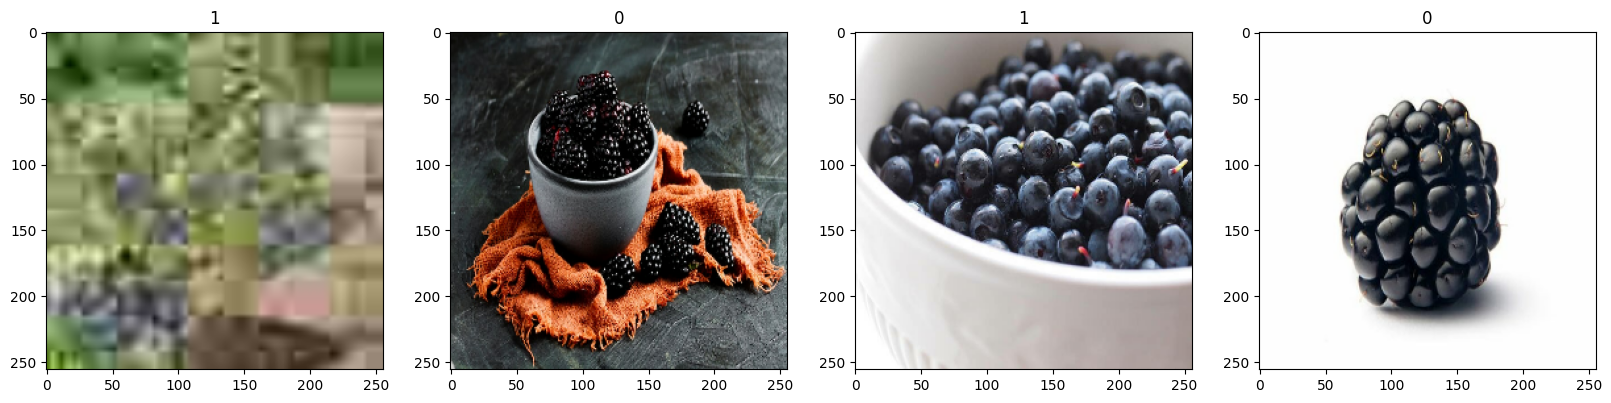

In [16]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])   

### Scaling the data - to values between 0 and 1 for model interpretation

In [ ]:
#scaled_data = data.map(lambda x, y: ((x/255), y))

In [18]:
scaled_iterator = scaled_data.as_numpy_iterator()

In [19]:
scaled_batch = scaled_iterator.next()

In [20]:
scaled_batch

(array([[[[0.6610149 , 0.73160315, 0.8257208 ],
          [0.6454935 , 0.71608174, 0.8101994 ],
          [0.648656  , 0.71924424, 0.8133619 ],
          ...,
          [0.32286304, 0.36992186, 0.42482385],
          [0.32120097, 0.36825982, 0.42316177],
          [0.30772826, 0.35478708, 0.40968904]],
 
         [[0.6511183 , 0.7217065 , 0.81582415],
          [0.6489507 , 0.7195389 , 0.81365657],
          [0.65643704, 0.7270253 , 0.8211429 ],
          ...,
          [0.32054675, 0.36760557, 0.42250752],
          [0.32101715, 0.36807597, 0.42297795],
          [0.30952817, 0.35658702, 0.41148898]],
 
         [[0.65268844, 0.7232767 , 0.8173943 ],
          [0.6621017 , 0.73269   , 0.8268076 ],
          [0.6681477 , 0.7387359 , 0.83285356],
          ...,
          [0.3305683 , 0.36586243, 0.42468596],
          [0.32922795, 0.36452207, 0.4233456 ],
          [0.32172543, 0.35701954, 0.41584307]],
 
         ...,
 
         [[0.7567168 , 0.827305  , 0.9135795 ],
          [0.75935

In [21]:
scaled_batch[0].max()   # confirms the max value = 1

np.float32(1.0)

### Data Split - Validate / Train / Test

In [52]:
train_size = int(len(data)*0.6)  #60% of the data goes to train
val_size = int(len(data)*0.2)
test_size = int(len(data)*0.2)

In [53]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size + val_size).take(test_size)

### Deep Learning Model

In [56]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, RandomFlip, RandomRotation, RandomZoom, RandomBrightness, RandomContrast, Rescaling
from tensorflow import keras

In [55]:
# Create the model

model = Sequential()

In [57]:
model.add(Rescaling(1./255))

# Augmentation layers
model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

# First CNN layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(256, 256, 3)))   # color blobs, edges
model.add(MaxPooling2D())

# Second CNN layer
model.add(Conv2D(64, (3,3), activation='relu'))   # texture (drupelets, skin)
model.add(MaxPooling2D())

# Third CNN layer
model.add(Conv2D(128, (3,3), activation='relu'))  # shape + color combos
model.add(MaxPooling2D())

model.add(Dropout(0.3))      
model.add(Flatten())         
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))      
model.add(Dense(6, activation='softmax'))   


c:\Users\vpete\Documents\NOD_Coding\Bootcamp\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [58]:
model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# use 'sparcecategoricalcrossentropy' as i have 6 categories. 

In [59]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ ?                      │   0 (unbuilt) │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness_1             │ ?                      │   0 (unbuilt) │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ ?                      │   0 (unbuilt) │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Clear any existing model
tf.keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))  # fixes the unbuilt issue

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,750 (56.61 MB)

 Trainable params: 14,839,750 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

In [60]:
logdir = "logs"

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir = logdir
)
# save history, so we can look to see how accuracy changes.

In [62]:
from tensorflow.keras.callbacks import EarlyStopping


In [63]:
# Train model on training data

## early stopping is so that if validation does not improve, model stops running

early_stopping = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=5,             # stop if no improvement for 5 epochs
    restore_best_weights=True  # rewind to best epoch when done
)

model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trained_model = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - accuracy: 0.1692 - loss: 7.3187 - val_accuracy: 0.2043 - val_loss: 1.7926
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.1875 - loss: 1.7941 - val_accuracy: 0.2788 - val_loss: 1.7461
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.1898 - loss: 1.7912 - val_accuracy: 0.2019 - val_loss: 1.7785
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 340ms/step - accuracy: 0.1890 - loss: 1.8040 - val_accuracy: 0.1803 - val_loss: 1.7319
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 328ms/step - accuracy: 0.1905 - loss: 1.8148 - val_accuracy: 0.2139 - val_loss: 1.7837
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 327ms/step - accuracy: 0.1837 - loss: 1.7919 - val_accuracy: 0.2500 - val_loss: 1.8826
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 341ms/step - accuracy: 0.1860 - loss: 1.8089 - val_accuracy: 0.2139 - val_loss: 1.8173
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 323ms/step - accuracy: 0.1921 - loss: 1.7899 - val_accu

In [51]:
print(data.class_names)
print(f"Total batches: {len(scaled_data)}")
print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")

['blackberries_bjornbar', 'blueberries_blabar', 'cloudberries_hjortron', 'lingonberries', 'raspberries_hallon', 'swedish_red_currant']
Total batches: 69
Train: 41, Val: 13, Test: 13


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [1.5026855..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with R

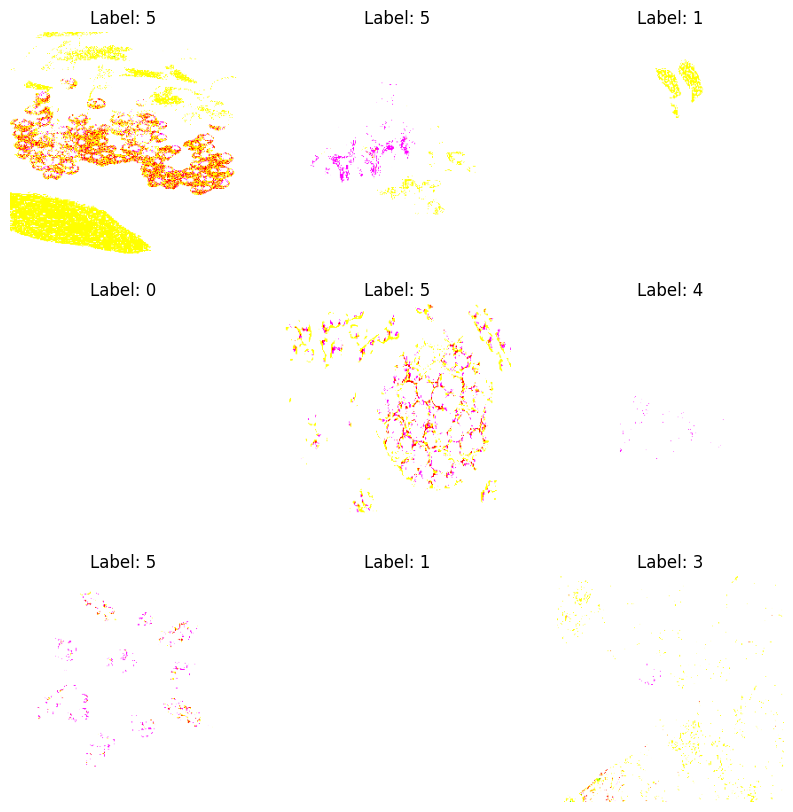

In [64]:
import matplotlib.pyplot as plt

# grab one batch
batch_images, batch_labels = next(iter(train))

# plot 9 images
plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(batch_images[i].numpy())
    plt.title(f"Label: {batch_labels[i].numpy()}")
    plt.axis('off')
plt.show()

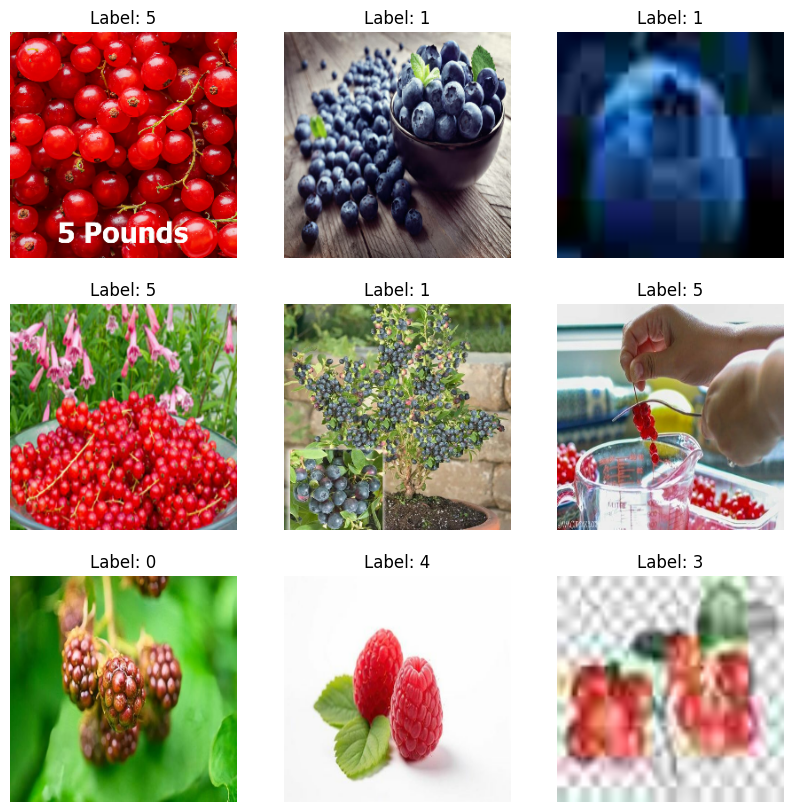

In [65]:
# Look at RAW data before any scaling
raw_batch_images, raw_batch_labels = next(iter(data))

plt.figure(figsize=(10,10))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(raw_batch_images[i].numpy().astype("uint8"))
    plt.title(f"Label: {raw_batch_labels[i].numpy()}")
    plt.axis('off')
plt.show()

In [66]:
# Clear any existing model
tf.keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))  # fixes the unbuilt issue

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

model.add(Rescaling(1./255))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,750 (56.61 MB)

 Trainable params: 14,839,750 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
logdir = "logs"

tensorboard_callback = tf.keras.callbacks.TensorBoard(
    log_dir = logdir
)
# sav

In [68]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=5,             # stop if no improvement for 5 epochs
    restore_best_weights=True  # rewind to best epoch when done
)

model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trained_model = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 340ms/step - accuracy: 0.3224 - loss: 1.9229 - val_accuracy: 0.6058 - val_loss: 1.0857
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 330ms/step - accuracy: 0.5564 - loss: 1.1968 - val_accuracy: 0.5817 - val_loss: 1.0475
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 333ms/step - accuracy: 0.5846 - loss: 1.0808 - val_accuracy: 0.6514 - val_loss: 0.9021
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.6204 - loss: 1.0062 - val_accuracy: 0.6442 - val_loss: 0.9116
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 331ms/step - accuracy: 0.6189 - loss: 1.0649 - val_accuracy: 0.6538 - val_loss: 0.9557
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.6601 - loss: 0.9482 - val_accuracy: 0.6923 - val_loss: 0.8414
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 330ms/step - accuracy: 0.6860 - loss: 0.8413 - val_accuracy: 0.7212 - val_loss: 0.7642
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 331ms/step - accuracy: 0.7172 - loss: 0.7857 - val_accu

In [69]:
##################### Re-running with adjusted ADAM learning rate (decrease from defaul 0.01 to reduce size of weight adjustment between batches)

# Clear any existing model
tf.keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))  # fixes the unbuilt issue

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

model.add(Rescaling(1./255))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,750 (56.61 MB)

 Trainable params: 14,839,750 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [70]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [71]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=5,             # stop if no improvement for 5 epochs
    restore_best_weights=True  # rewind to best epoch when done
)

model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trained_model = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 342ms/step - accuracy: 0.2843 - loss: 1.8902 - val_accuracy: 0.3942 - val_loss: 1.3804
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 328ms/step - accuracy: 0.4078 - loss: 1.4089 - val_accuracy: 0.5168 - val_loss: 1.1444
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 328ms/step - accuracy: 0.5373 - loss: 1.1973 - val_accuracy: 0.5649 - val_loss: 1.1287
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 329ms/step - accuracy: 0.5610 - loss: 1.1216 - val_accuracy: 0.6058 - val_loss: 0.9402
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 13s 326ms/step - accuracy: 0.5663 - loss: 1.0943 - val_accuracy: 0.5288 - val_loss: 1.0762
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 303ms/step - accuracy: 0.5915 - loss: 1.0692 - val_accuracy: 0.6707 - val_loss: 0.9543
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.6136 - loss: 0.9997 - val_accuracy: 0.5817 - val_loss: 1.0800
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.6159 - loss: 0.9766 - val_accu

In [72]:
##################### Re-running with patience = 10 added so that early stop does not kick in too early

# Clear any existing model
tf.keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))  # fixes the unbuilt issue

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

model.add(Rescaling(1./255))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,750 (56.61 MB)

 Trainable params: 14,839,750 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [73]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [74]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=10,             # stop if no improvement for 10 epochs
    restore_best_weights=True  # rewind to best epoch when done
)

model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trained_model = model.fit(
    train,
    validation_data=val,
    epochs=50,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - accuracy: 0.3117 - loss: 1.7719 - val_accuracy: 0.4736 - val_loss: 1.2843
Epoch 2/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 330ms/step - accuracy: 0.5236 - loss: 1.2718 - val_accuracy: 0.6106 - val_loss: 0.9929
Epoch 3/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 344ms/step - accuracy: 0.5739 - loss: 1.0998 - val_accuracy: 0.6731 - val_loss: 0.9700
Epoch 4/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 300ms/step - accuracy: 0.5968 - loss: 1.0678 - val_accuracy: 0.6851 - val_loss: 0.8731
Epoch 5/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step - accuracy: 0.6380 - loss: 0.9588 - val_accuracy: 0.6635 - val_loss: 0.8650
Epoch 6/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step - accuracy: 0.6380 - loss: 0.9972 - val_accuracy: 0.6683 - val_loss: 0.8856
Epoch 7/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 295ms/step - accuracy: 0.6433 - loss: 0.9199 - val_accuracy: 0.6971 - val_loss: 0.8318
Epoch 8/50
41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 297ms/step - accuracy: 0.6410 - loss: 0.9232 - val_accu

In [75]:
##################### Re-running with epochs = 100

# Clear any existing model
tf.keras.backend.clear_session()

model = keras.Sequential()

model.add(keras.Input(shape=(256, 256, 3)))  # fixes the unbuilt issue

model.add(RandomFlip("horizontal"))
model.add(RandomRotation(0.2))
model.add(RandomZoom(0.2))
model.add(RandomBrightness(0.2))
model.add(RandomContrast(0.2))

model.add(Rescaling(1./255))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(6, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 256, 256, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_brightness               │ (None, 256, 256, 3)    │             0 │
│ (RandomBrightness)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast                 │ (None, 256, 256, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,839,750 (56.61 MB)

 Trainable params: 14,839,750 (56.61 MB)

 Non-trainable params: 0 (0.00 B)

In [76]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [77]:
early_stopping = EarlyStopping(
    monitor='val_loss',     # watch validation loss
    patience=10,             # stop if no improvement for 10 epochs
    restore_best_weights=True  # rewind to best epoch when done
)

model.compile(
    optimizer="adam",
    loss=tf.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

trained_model = model.fit(
    train,
    validation_data=val,
    epochs=100,
    callbacks=[early_stopping, tensorboard_callback]
)

Epoch 1/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 16s 353ms/step - accuracy: 0.3681 - loss: 1.6984 - val_accuracy: 0.5889 - val_loss: 1.1583
Epoch 2/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 337ms/step - accuracy: 0.5587 - loss: 1.1987 - val_accuracy: 0.6202 - val_loss: 1.0440
Epoch 3/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 336ms/step - accuracy: 0.5991 - loss: 1.0773 - val_accuracy: 0.5889 - val_loss: 1.0037
Epoch 4/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 337ms/step - accuracy: 0.5808 - loss: 1.0411 - val_accuracy: 0.6490 - val_loss: 0.9376
Epoch 5/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 335ms/step - accuracy: 0.6120 - loss: 1.0078 - val_accuracy: 0.6346 - val_loss: 0.9656
Epoch 6/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 334ms/step - accuracy: 0.6189 - loss: 0.9557 - val_accuracy: 0.6514 - val_loss: 0.9163
Epoch 7/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 330ms/step - accuracy: 0.6235 - loss: 0.9522 - val_accuracy: 0.7260 - val_loss: 0.7985
Epoch 8/100
41/41 ━━━━━━━━━━━━━━━━━━━━ 14s 334ms/step - accuracy: 0.6707 - loss: 0.8910 - 

In [78]:
test_loss, test_accuracy = model.evaluate(test)
print(f"Test accuracy: {test_accuracy:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8293 - loss: 0.5764
Test accuracy: 0.8293


In [80]:
import sys
!{sys.executable} -m pip install scikit-learn

c:\Users\vpete\Documents\NOD_Coding\Bootcamp\.venv\Scripts\python.exe: No module named pip


In [81]:
import subprocess
subprocess.check_call(["python", "-m", "ensurepip"])
subprocess.check_call(["python", "-m", "pip", "install", "scikit-learn"])

CalledProcessError: Command '['python', '-m', 'ensurepip']' returned non-zero exit status 1.

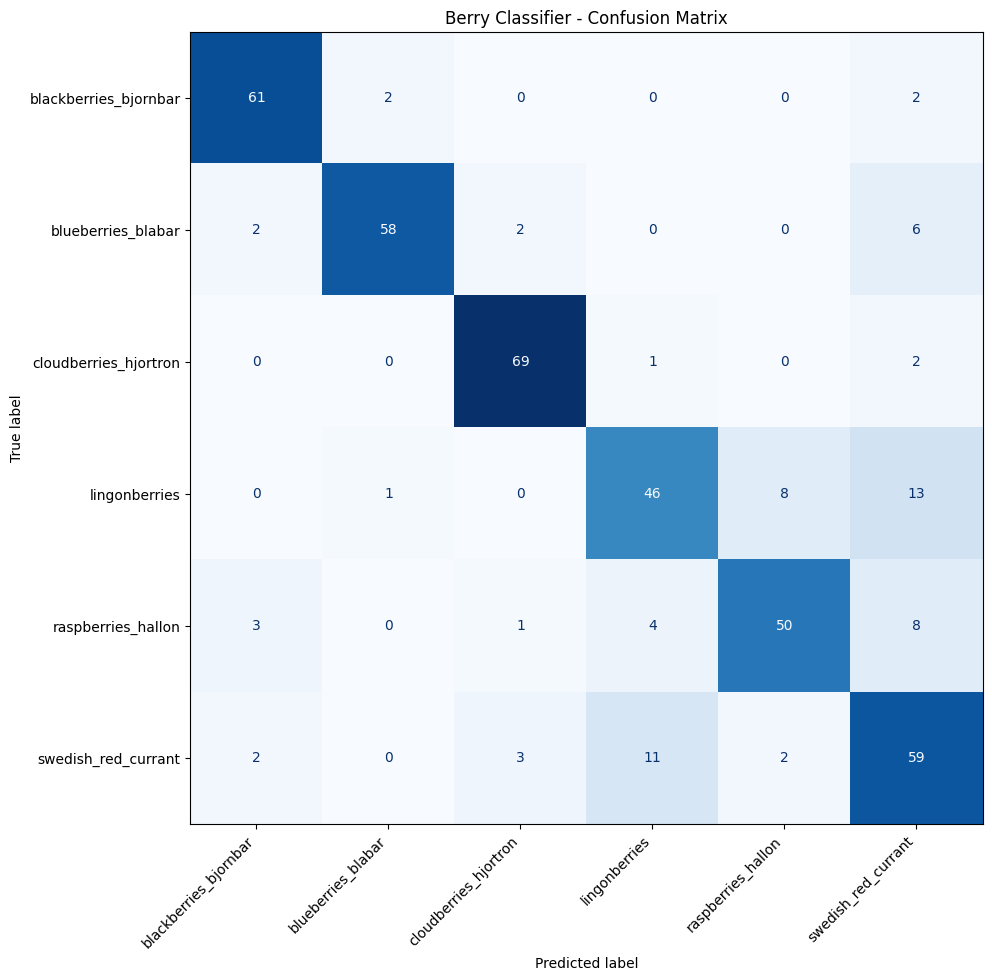

In [82]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions from test set
y_true = []
y_pred = []

for images, labels in test:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

# Class names from your dataset
class_names = data.class_names

# Build and plot confusion matrix
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.xticks(rotation=45, ha='right')
plt.title('Berry Classifier - Confusion Matrix')
plt.tight_layout()
plt.show()